<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Métodos baseados em vizinhança - k-vizinhos mais próximos</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> e <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>  

 <hr style="height:2px"> 


## Introdução

O método de **$k$-vizinhos mais próximos**, ou KNN, é uma técnica simples de eficaz de aprendizado de máquina que pode ser utilizado para problemas de classificação ou regressão [1]. Partindo do pressuposto de que amostras similares compartilharão a mesma classe ou valor-alvo, o algoritmo classifica um novo dado com base em seus $k$ vizinhos mais próximos, isto é, as $k$ amostras mais similares ao dado. Esta similaridade é tradicionalmente definida em termos de uma métrica de distância, como a distância euclidiana ou de Manhattan.

Sendo um algoritmo intuitivo e de fácil implementação, é comumente empregado como um primeiro passo em problemas de classificação, podendo obter resultados satisfatórios de acordo com as características dos dados do problema. Ainda assim, o algoritmo apresenta limitações, como a sensibilidade a outliers, dados ruidosos e atributos em diferentes escalas de magnitude. O valor adotado de $k$, previamente selecionado antes da execução do método, também deve ser cuidadosamente escolhido, de forma a evitar problemas de super ou subajustamento.

Ao longo deste *notebook*, todas etapas do método de $k$-vizinhos mais próximo serão implementadas e aplicadas em um problema de classificação. Inicialmente os dados serão normalizados, mitigando problemas de escalas diferentes. Em seguida, será feita a implementação do cálculo da distância, no qual será empregado distância euclidiana. Finalmente, o classificador será implementado, utilizando as funções previamente mencionadas.

Durante o *notebook*, dfierentes gráficos serão exibidos, facilitando a compreensão do KNN e da distribuição dos dados em um plano vetorial. Ao término do *notebook* será ensinado como o método pode ser utilizado através da biblioteca `scikit-learn`, que emprega diversas técnicas para otimizá-lo.

Este *notebook* se refere ao Capítulo **4 (Métodos baseados em vizinhança)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`sklearn`](https://scikit-learn.org/stable/) (versão 1.0.2 ou superior): execução da versão otimizada do KNN

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`, em formato de arquivo `.csv`.

---
## Visualização dos dados

Primeiro, iremos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np # importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # importa a biblioteca usada para trabalhar com dataframes (dados em formato de tabela) e análise de dados
import os # importa a biblioteca built-in do python para trabalhar com o sistema operacional

import sklearn as skl
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


Iremos criar uma base de dados usando a classe *make_classification* da biblioteca *sklearn*. 

In [2]:
# Gerar dados de classificação
X, Y = skl.datasets.make_classification(n_samples=500, n_features=2, n_classes=2, n_informative=2, 
                                        n_redundant=0, n_clusters_per_class=1, class_sep = 2.3,  
                                        flip_y = 0.0, random_state=10)

# Imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# Imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

'X:'

array([[ 2.57155249, -3.39646407],
       [ 1.97644376, -1.5458409 ],
       [ 4.52009067, -5.57131377],
       [-0.74742755, -1.50460319],
       [-4.20023176, -1.78002802]])

Y: [0 0 0 1 1]


Vamos criar uma função para exibir os dados.

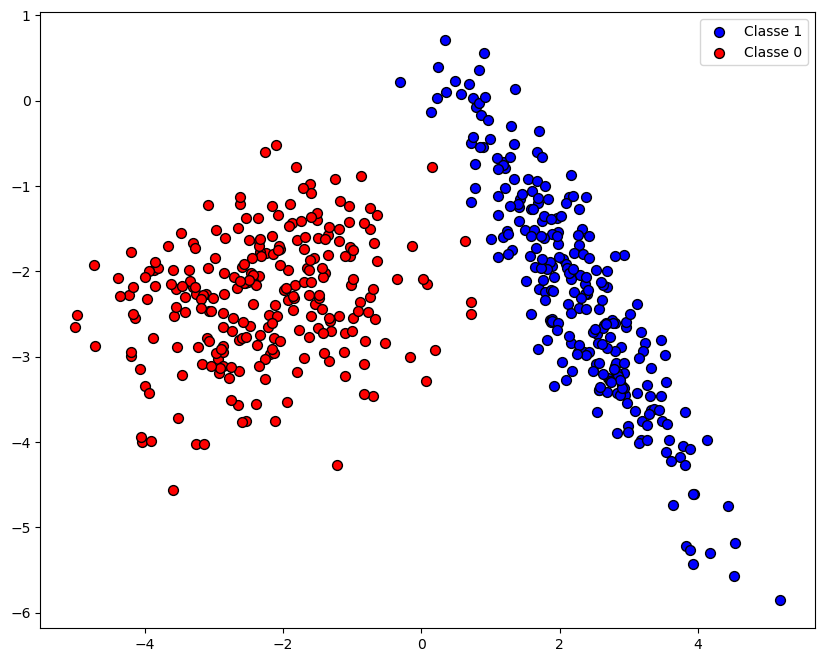

In [3]:
#importa a biblioteca matplotlib
import matplotlib.pyplot as plt

#função para plotar os dados
def visualizarDados(X,Y):
    """
    Função usada para plotar os dados
    """
    
    #define o tamanho da figura 
    plt.figure(figsize=(10,8))
    
    #plota os dados da classe 0
    plt.scatter( X[Y==0,0], X[Y==0,1], label='Classe 1', color='blue', s=50, edgecolors='k') 
    
    #plota os dados da classe 1
    plt.scatter( X[Y==1,0], X[Y==1,1], label='Classe 0', color='red', s=50, edgecolors='k') 
        
    #plota a legenda
    plt.legend()
    
#chama a função que plota os dados   
visualizarDados(X,Y)
plt.show()

---
## Normalização dos dados

Como a distância entre as amostras pode ser influenciada pela escala
dos atributos, é recomendável que os atributos sejam normalizados de
forma que a média seja igual a 0 e desvio padrão igual a 1. 

In [4]:
# normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
scaler = skl.preprocessing.StandardScaler().fit(X)
X_norm = scaler.transform(X)

# Exibe o conteúdo das amostras
print('\nPrimeira amostra da base antes da normalização: [%2.4f %2.4f].' %(X[0,0],X[0,1]))

print('\nPrimeira amostra da base após normalização: [%2.4f %2.4f].' %(X_norm[0,0],X_norm[0,1]))

# Exibe a média
mu = np.mean(X, axis=0)
mu_norm = np.mean(X_norm, axis=0)

print('---\nMédia dos atributos antes da normalização:  [%2.4f %2.4f].' %(mu[0], mu[1]))

print('\nMédia dos atributos após normalização:  [%2.4f %2.4f].' %(mu_norm[0], mu_norm[1]))

# Exibe o desvio padrão
sigma = np.std(X, axis=0, ddof=1)
sigma_norm = np.std(X_norm, axis=0, ddof=1)

print('---\nDesvio padrão dos atributos antes da normalização:  [%2.4f %2.4f].' %(sigma[0], sigma[1]))

print('\nDesvio padrão dos atributos após normalização:  [%2.4f %2.4f].' %(sigma_norm[0], sigma_norm[1]))


Primeira amostra da base antes da normalização: [2.5716 -3.3965].

Primeira amostra da base após normalização: [1.0429 -1.0679].
---
Média dos atributos antes da normalização:  [-0.0070 -2.2869].

Média dos atributos após normalização:  [-0.0000 0.0000].
---
Desvio padrão dos atributos antes da normalização:  [2.4750 1.0401].

Desvio padrão dos atributos após normalização:  [1.0010 1.0010].


---
## Classificação de novos dados

Abaixo, criaremos um novo caso de teste para ser classificado.

In [5]:
# Definição do primeiro caso de teste.
x_teste = np.array(([[0.5, -1.0]])) # Você pode testar outros valores aqui

Vamos exibir essa amostra.

Exibindo caso de teste: [0.5000 -1.0000] (quadrado verde do gráfico). 



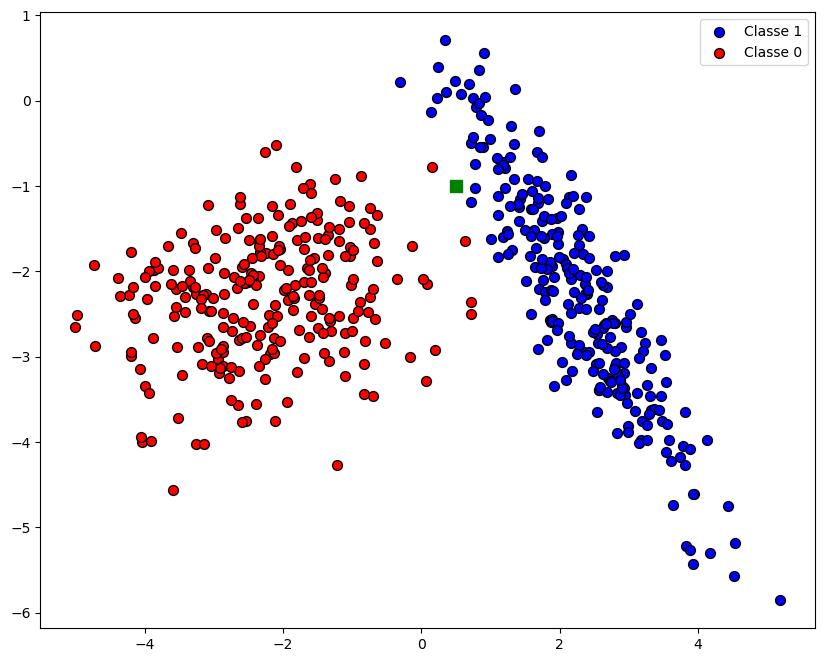

In [6]:
print('Exibindo caso de teste: [%2.4f %2.4f] (quadrado verde do gráfico). \n' %(x_teste[0,0],x_teste[0,1]))

# Plotando os dados de treinamento 
visualizarDados(X, Y)

# Visualizando o caso de teste junto com os dados de treinamento
plt.scatter(x_teste[0,0], x_teste[0,1], marker='s', color='green', s=80)

# exibe o grafico
plt.show()

Agora, vamos normalizar o caso de teste usando o modelo de normalização ajustado anteriormente com os dados de treinamentos.

In [7]:
# Normaliza o caso de teste usando os valores de mu e sigma pré-calculados
x_teste_norm = scaler.transform(x_teste)

print('\nAmostra de teste normalizada: [%2.4f %2.4f].' %(x_teste_norm[0,0],x_teste_norm[0,1]))


Amostra de teste normalizada: [0.2051 1.2386].


---
## Método dos $k$-vizinhos mais próximos

Nesta etapa, o método dos $k$-vizinhos será implementado e utilizado para predizer a classe de uma nova amostra. Primeiro, implementaremos a função que calcula a distância Euclidiana entre dois vetores quaisquer (**distancia()**) e, posteriormente, o código referente ao método do $k$-NN (**knn()**).
  
A distância Euclidiana é calculada usando a seguinte equação: $dist(x,y) = \sqrt{\sum_{i=1}^{n} (x_i-y_i)^2}$.

A equação mostrada acima, também pode ser definida da seguinta forma: $dist(x,y) = \left\Vert x-y \right\Vert_2$.

Nas equações mostradas acima, $x$ e $y$ são vetores que possuem a mesma dimensão ($n$).

Vamos então implementar a função de distância. Essa função deverá calcular a distância entre $x$ e cada amostra de $X^{(i)}$.

In [8]:
def distancia(x, X):
    """
    DISTANCIA calcula a distância euclidiana entre a amostra x e todos as
    amostras da base X.
    D = DISTANCIA (x, X) retorna um vetor de distâncias entre a amostra x 
    e todas as amostras da base X. Cada posição Di = dist(x, Xi).
    """ 

    # Calcula a distancia euclidiana
    sqr_diff = np.power(x - X, 2)
    sum_sqr_diff = np.sum(sqr_diff, axis=1)
    D = np.sqrt(sum_sqr_diff)
    
    return D

D = distancia(x_teste_norm, X_norm)
print(D)

[2.45394227 0.79534253 4.69049369 0.70028712 2.04386968 0.59352057
 1.03504288 2.45010759 0.42715637 1.72276342 0.40160729 2.87130519
 1.46709959 1.04189596 0.74397407 1.04417807 0.48684134 0.92950385
 3.12860021 3.0836425  2.90941757 2.26400986 2.39747524 2.92153901
 0.68538318 2.00070875 1.25925858 1.06812245 1.02286044 3.284825
 1.86398615 1.65300143 2.15494783 1.81541249 1.37877023 2.69776137
 1.82850478 1.00181557 1.79261104 0.63930993 1.53707028 1.30650104
 2.03733249 3.22416867 2.77814994 0.40421744 1.56086562 1.14867637
 0.43462344 0.67333911 2.26834694 3.2279124  2.44620275 2.00992883
 1.91978983 1.4947122  2.37568361 2.00082715 1.95130668 1.54837361
 0.50661625 1.78632901 0.34825133 1.90757105 0.69313261 0.76469532
 1.92454063 1.80283693 0.62218024 2.44173157 2.17315908 2.25449822
 0.71105249 0.76917189 1.85750686 0.58063706 2.55672251 1.79003209
 1.81688075 2.56142889 0.38176972 2.32677927 2.0580463  0.78348213
 1.26899307 2.63200685 2.74619821 0.80189948 1.92247437 1.309725

Após calcular as distâncias $D$, é necessário encontrar os $K$ menores valores de $D$, que correspondem aos objetos (vizinhos) mais próximos da amostra de teste. Depois, é preciso selecionar a classe majoritária entre as $K$ amostras da base de dados e, então, usar essa classe para rotular a amostra de teste ($y$). Adicionalmente, recuperaremos os índices $ind\_viz_{(K \times 1)}$ correspondentes às posições (linhas) dos $K$-vizinhos encontrados em $X$.

Vamos implementar a função que calcula o $k$-NN.

**Dica**: 
* podemos utilizar a função **distancia()** criada anteriormente para calcular a distância euclidiana entre a amostra *x* e todas as amostras de treinamento *X*. 
* em Python, para retornar os índices do vetor A para que ele fique ordenado, basta usar ```np.argsort(A)```. Exemplo: Se **A=[4,2,3,1]**, ao usar o código ```idxA_ord = np.argsort(A)```, os valores de **idxA_ord** serão **[3,1,2,3]**. 
* no Python, para calcular a quantidade de vezes que um valor *v* se repete em um vetor *A*, pode-se usar o código ```np.sum(A==v)```.

In [9]:
def knn(x, X, Y, K):
    """
    KNN método dos K-vizinhos mais proximos para predizer a classe de um novo
    dado.

    KNN (x, X, Y, K) retorna o rótulo y da amostra x e os índices
        [ind_viz] dos K-vizinhos mais próximos de x em X.
 
        Parâmetros de entrada:
        -> x (1 x n): amostra a ser classificada
        -> X (m x n): base de dados de treinamento
        -> Y (m x 1): conjunto de rótulos de cada amostra de X
        -> K (1 x 1): quantidade de vizinhos mais próximos
 
        Parâmetros de saída:
        -> y (1 x 1): predição (0 ou 1) do rótulo da amostra x
        -> ind_viz (K x 1): índice das K amostras mais próximas de x
                            encontradas em X (da mais próxima para a menos
                            próxima)
    """
    # Calcula a distância entre a amostra de teste x e cada amostra de X
    D = distancia(x, X)
    
    # Guarda o índice ordenado das distâncias
    ind_ord = np.argsort(D)

    # Recupera os k vizinhos mais próximos
    ind_viz = ind_ord[0:K] # pega os indices dos k vizinhos mais próximos
    y_viz = Y[ind_viz] # pega as classes dos dos k vizinhos mais próximos

    # Conta a ocorrencia de cada classe
    qtd_viz_classe0 = np.sum( y_viz==0 ) # conta a quantidade de vizinhos da classe 0
    qtd_viz_classe1 = np.sum( y_viz==1 ) # conta a quantidade de vizinhos da classe 1
    
    # Faz a contagem de votos entre os k vizinhos para decidir a classe do caso de teste
    if qtd_viz_classe0 > qtd_viz_classe1:
        y = 0
    else:
        y = 1
        
    return y, ind_viz

Agora, vamos testar o $k$-NN usando a função que acabamos de implementar. 

Um importante parâmetro do método K-NN é a quantidade de vizinhos $K$ que será usadao para a escolha da classe da amostra de teste. Esse parâmetro, em problemas de classificação binários, é normalmente um valor ímpar 1, 3 ou 5, de forma a se evitar empates entre as classes.

No código abaixo, você poderá alterar a quantidade de vizinhos (<tt>K</tt>).

In [10]:
# Define o caso de teste
x_teste = np.array(([[0.2, -1.0]])) # Você pode testar outros valores aqui

# Define a quantidade de vizinhos. Recomenda-se que seja ímpar (1, 3, ou 5)
K = 5 # você pode testar outros valores aqui

# Normaliza o caso de teste usando o modelo de normalização
x_teste_norm = scaler.transform(x_teste)

# Chama o algoritmo do k-vizinhos para predizer o rótulo da amostra de teste.
y, ind_viz = knn(x_teste_norm, X_norm, Y, K)

# Exibe o rótulo da amostra de teste retornado pelo algoritmo KNN
print('Segundo o KNN para K={}, a amostra de teste foi classificada como:'.format(K))

# Imprime a espécie da planta de acordo com o rótulo informado
if y == 0:
    print('\tClasse 0.\n');
else:
    print('\tClasse 1.\n');

Segundo o KNN para K=5, a amostra de teste foi classificada como:
	Classe 0.



É interessante notar que a alteração no valor de $K$ no código acima, ocasiona a alteração da classe predita pelo classificador. Para $K=1$, a amostra de teste é classificada como **Classe 1**. Porém, para $K=3$ ou $K=5$, a amostra de teste é classificada como **Classe 0**.

Agora, vamos visualizar o(s) $k$-vizinho(s) mais próximo(s) usado(s) na classificação.


Visualizando o(s) 5-vizinho(s) mais próximo(s) usado(s) na classificação.




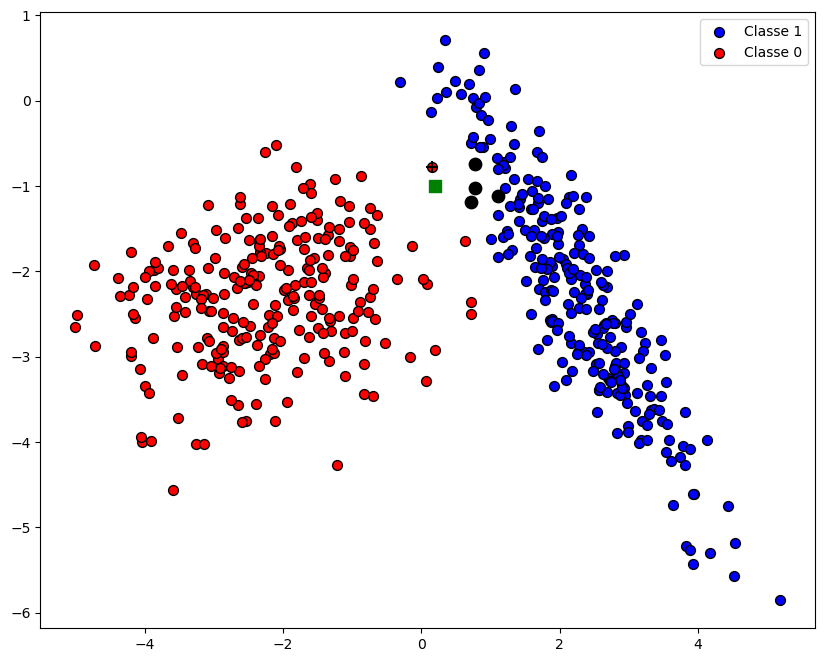

In [11]:
print('\nVisualizando o(s) %d-vizinho(s) mais próximo(s) usado(s) na classificação.\n\n' %K);

# Plotando os dados de treinamento 
visualizarDados(X,Y)

# Visualizando o caso de teste junto com os dados de treinamento
plt.scatter( x_teste[0,0], x_teste[0,1], marker='s', color='green', s=80)

for i in range(K):
    if Y[ind_viz[i]]==0:
            plt.scatter( X[ind_viz[i],0], X[ind_viz[i],1], label="Classe 1", marker='o', color='black', s=80)
    else:
            plt.scatter( X[ind_viz[i],0], X[ind_viz[i],1], label="Classe 2", marker='+', color='black', s=80) 
  
plt.show()

Vamos dar uma olhada na superfície de decisão aprendida pelo KNN. Troque o valor de $K$ para ver diferentes superficies de decisão.

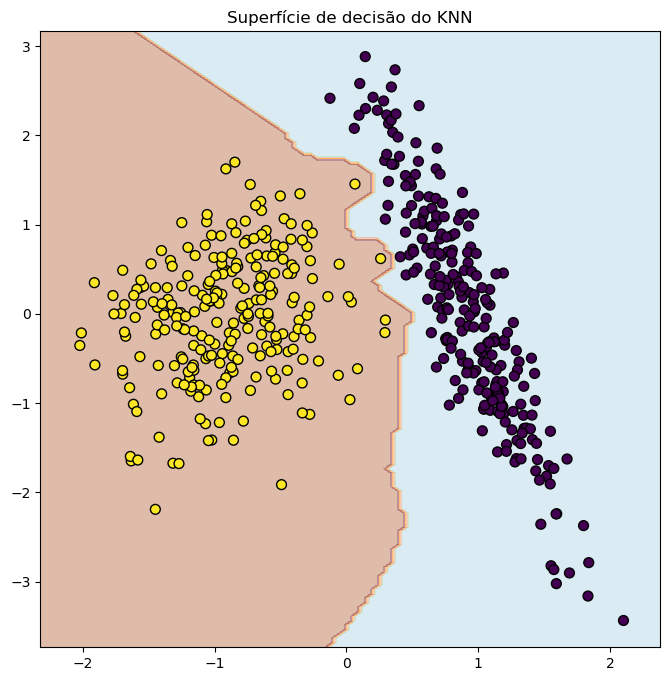

In [12]:
def superficie_decisao(X, Y, K, ax, title=""):
    h = .05  # tamanho do passo da malha (mesh)

    # cria uma malha (mesh)
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
     
    X_teste = np.c_[xx.ravel(), yy.ravel()]
    
    Z = np.zeros(X_teste.shape[0])
    for i in range(X_teste.shape[0]):
    
        # Chama o algoritmo do k-vizinhos para predizer o rótulo da amostra de teste.
        Z[i], ind_viz = knn(X_teste[i], X, Y, K)
    
    # Converte os valores do vetor para indices
    Z2 = np.unique(Z, return_inverse=True)[1]

    # Desenha a superficie de decisao
    Z2 = Z2.reshape(xx.shape)
    ax.contourf(xx, yy, Z2, cmap=plt.cm.Paired, alpha=.4)

    # Converte os valores do vetor para indices
    Y2 = np.unique(Y, return_inverse=True)[1]

    # Exibe os dados de treinamento
    ax.scatter(X[:, 0], X[:, 1], c=Y2, edgecolor='k', s=50)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title, fontsize='large')
    

# Define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# Define o valor de K
K=1 # você pode testar outros valores aqui

# chama a função para desenhar a superfície de decisão juntamente com os dados de teste
superficie_decisao(X_norm, Y, K, ax, title="Superfície de decisão do KNN")

plt.show()

---
## Exemplo usando outra base de dados

Agora, vamos testar o método com um exemplo mais complexo (_Virginica_ x _Versicolor_). 

'X:'

array([[ 0.61539209, -0.32003052],
       [-0.72249634, -0.61945851],
       [-0.46296941, -0.79173367],
       [-1.25657305, -1.29747569],
       [-1.08236486, -1.19737903]])

Y: [0 1 1 1 1]


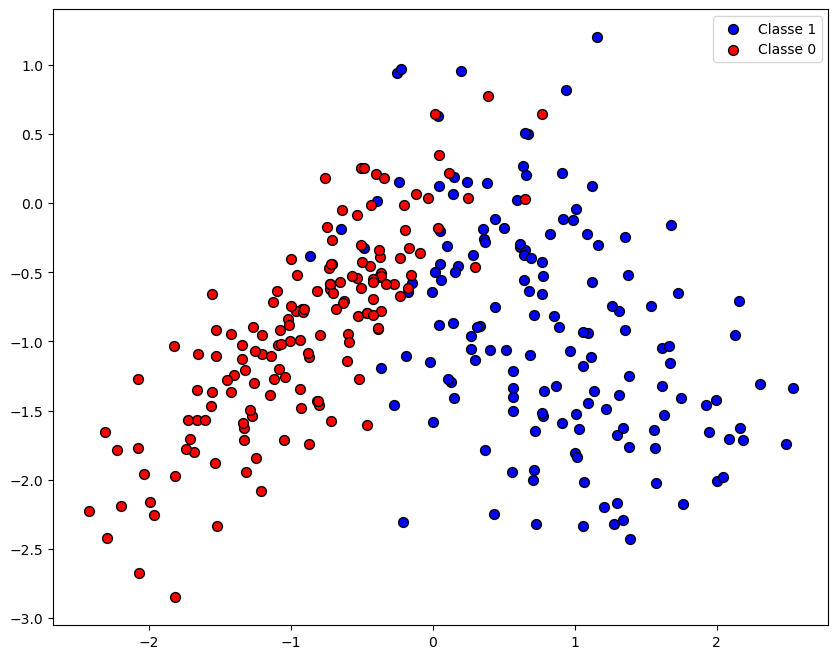

In [13]:
X2, Y2 = skl.datasets.make_classification(n_samples=300, n_features=2, n_classes=2, n_informative=2, 
                                        n_redundant=0, n_clusters_per_class=1, class_sep = 0.9,  
                                        flip_y = 0.0, random_state=10)

# imprime as 5 primeiras linhas da matriz X
display('X:', X2[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y2[0:5])

# plota os dados de treinamento
visualizarDados(X2,Y2)
plt.show()

Agora, os dados serão normalizados.

In [14]:
# Normalizar os dados
scaler2 = skl.preprocessing.StandardScaler().fit(X2)
X2_norm = scaler2.transform(X2)

Agora, vamos criar manualmente um novo caso de teste.

In [15]:
# Definição de um novo caso de teste
x2_teste = np.array(([[-0.1, 0.2]])) # você pode testar outros valores aqui

Plotando o caso de teste junto aos dados de treinamento.


Visualizando o caso de teste: [-0.1000 0.2000].



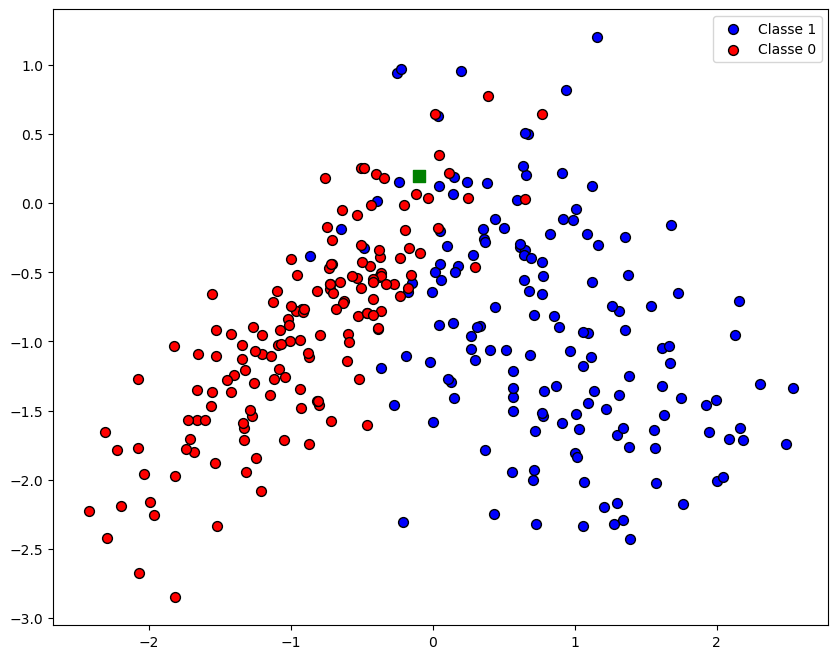

In [16]:
print('\nVisualizando o caso de teste: [%2.4f %2.4f].\n' %(x2_teste[0,0],x2_teste[0,1]))

# Plotando os dados de treinamento 
visualizarDados(X2,Y2)

# Visualizando o caso de teste junto com os dados de treinamento
plt.scatter( x2_teste[0,0], x2_teste[0,1], marker='s', color='green', s=80)
plt.show()

 A seguir, a amostra de teste será normalizada usando o valor de $\mu$ e $\sigma$ calculados com a base nos dados de treinamento.

In [17]:
# Normaliza o caso de teste 
x2_teste_norm = scaler2.transform(x2_teste)

Finalmente, o $k$-NN é empregado para predizer a classe da amostra de teste. No código abaixo, você poderá alterar a quantidade de vizinhos (<tt>K</tt>) para verificar como o resultado é alterado.

In [18]:
# Define a quantidade de vizinhos. Recomenda-se que seja ímpar (1, 3, ou 5)
K = 5 # você pode testar outros valores aqui

# Chama o algoritmo do k-vizinhos para predizer o rótulo da amostra teste.
y2, ind_viz2 = knn(x2_teste_norm, X2_norm, Y2, K)

# Exibe o rótulo da amostra de teste retornado pelo algoritmo KNN
print('\nSegundo o KNN, para K={}, a amostra de teste será classificada como:'.format(K))

# Imprime a espécie da planta de acordo com o rótulo informado
if y2 == 0:
    print('\tClasse 0.\n')
else:
    print('\tClasse 1.\n')


Segundo o KNN, para K=5, a amostra de teste será classificada como:
	Classe 1.



É interessante notar que a alteração no valor de $K$ no código acima, ocasiona a alteração da classe predita pelo classificador. Para $K=1$ ou $K=3$, a amostra de teste é classificado como **Classe 0**. Porém, para $K=5$, a amostra de teste é classificada como **Classe 1**.

Em seguida, vamos plotar o(s) vizinho(s) mais próximo(s) usado(s) na classificação.


Visualizando o(s) 5-vizinho(s) mais próximo(s) usado(s) na classificação.




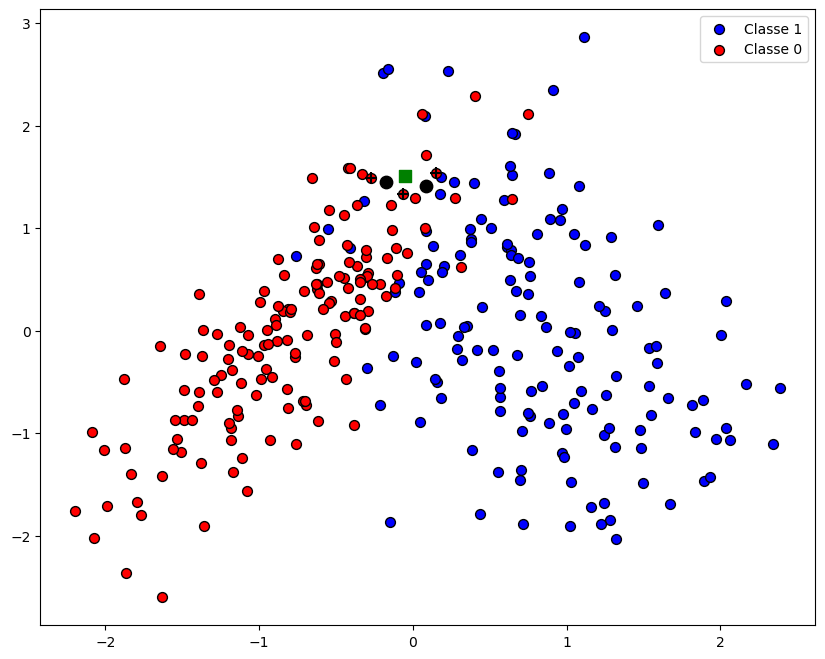

In [19]:
print('\nVisualizando o(s) %d-vizinho(s) mais próximo(s) usado(s) na classificação.\n\n' %K);

# Plotando os dados de treinamento 
visualizarDados(X2_norm, Y2)

# Visualizando o caso de teste junto com os dados de treinamento
plt.scatter(x2_teste_norm[0,0], x2_teste_norm[0,1], marker='s', color='green', s=80)

for i in range(K):
    if Y2[ind_viz2[i]]==0:
            plt.scatter( X2_norm[ind_viz2[i],0], X2_norm[ind_viz2[i],1], label="Classe 0", marker='o', color='black', s=80)
    else:
            plt.scatter( X2_norm[ind_viz2[i],0], X2_norm[ind_viz2[i],1], label="Classe 1", marker='+', color='black', s=80) 
  
plt.show()

Vamos olhar a superfície de decisão gerada pelo classificador. Mude o valor de $K$ para ver diferentes superfícies de decisão. 

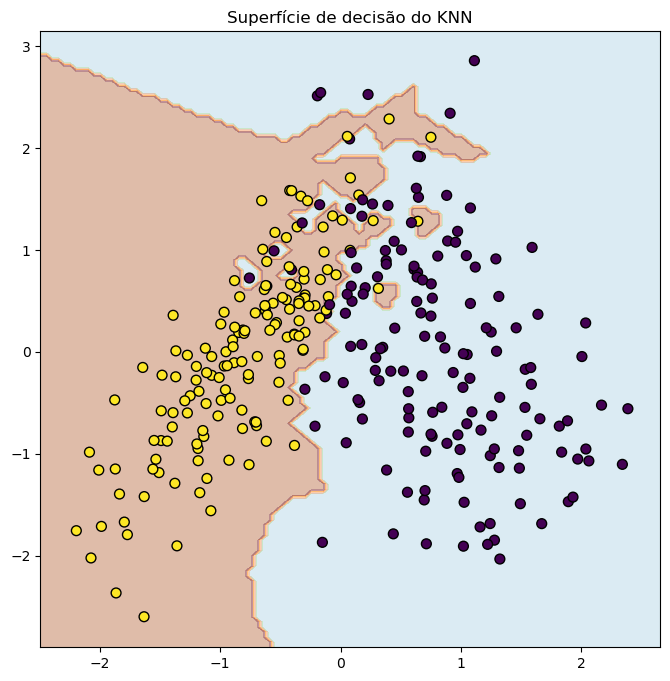

In [20]:
# Define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# Define o número de vizinhos
K=1 # você pode testar outros valores aqui

# Chama a função para plotar a superfície de decisão juntamente com os dados de teste
superficie_decisao(X2_norm, Y2, K, ax, title="Superfície de decisão do KNN")

plt.show()

---
## Otimizações e configurações do KNN

Ainda que bastante intuitivo e simples, o algoritmo de $k$-vizinhos mais próximos possui a limitação de ser bastante custoso para bases grandes, sendo necessário o constante cálculo da distância entre a amostra-alvo e todas as demais amostras no conjunto de dados. Entretanto, esta etapa pode ser acelerada utilizando estruturas de dados apropriadas para organização de dados em espaços multi-dimensionais, como *Ball trees* ou *K-D trees* [3].

Adicionalmente, o KNN permite mais configurações não adotadas nos códigos acima, como por exemplo:
* **Outras funções de distância**: neste *notebook*, implementamos apenas a distância euclidiana. Entretanto, outras métricas de distância poderiam ser adotadas, como **distância de cosseno** ou **distância de Manhattan**;
* **Ponderação das classes**: na implementação do KNN, selecionamos a classe predita de acordo com um voto majoritário dos vizinhos (isto é, a moda das classes dos vizinhos). Outras técnicas podem ser adotadas nessa etapa, como por exemplo o **voto ponderado de acordo com a distância**, no qual amostras mais similares terão maior peso na votação.

Todas estas técnicas de otimização e configurações podem ser encontradas na implementação do KNN na biblioteca ``scikit-learn`` [4]. A biblioteca é considerada a principal em Python sobre aprendizado de máquina, contendo vários algoritmos, bases de dados e tarefas amplamente utilizados na área.

Nesta etapa final do *notebook*, vamos executar o algoritmo do KNN usando a implementação do ``scikit-learn`` e verificar como diferentes parâmetros podem alterar o resultado.

#### Chamada do algoritmo KNN

O KNN está implementado na biblioteca através da classe ``sklearn.neighbors.KNeighborsClassifier``. Vamos importá-lo e entender melhor seus parâmetros.

In [21]:
# Instancia um novo objeto do método KNN
KNN_model = KNeighborsClassifier(
    n_neighbors=5, # número K de vizinhos
    weights='uniform', # define como a classe será escolhida. Neste caso, por voto majoritário
    algorithm='brute', # como será o cálculo da distância. Neste caso, da amostra alvo para todas as amostras
    metric='minkowski', p=2 #métrica de distância utilizada. Para minkowski e p=2, temos a dist euclidiana
)

KNN_model

KNeighborsClassifier(algorithm='brute')

Na célula acima, instanciamos uma versão do KNN idêntica a implementada no *notebook*. Vamos executá-la sobre a base de dados e fazer uma predição para uma nova amostra.

In [22]:
# Realiza o treinamento do modelo
KNN_model.fit(X2_norm, Y2)

# Gera a predição
pred_class = KNN_model.predict(x2_teste_norm)[0]

# Exibe o rótulo da amostra de teste retornado pelo algoritmo KNN
print('\nSegundo o KNN, a amostra de teste será classificada como:')

# Imprime a espécie da planta de acordo com o rótulo informado
if pred_class == 0:
    print('\tClasse 0.\n')
else:
    print('\tClasse 1.\n')


Segundo o KNN, a amostra de teste será classificada como:
	Classe 1.



Em seguida, iremos trocar os parâmetros de distância do KNN para ver como ele se comporta

In [23]:
# Instancia um novo objeto do método KNN
KNN_model_manhattan = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance', # vamos ponderar os votos de acordo com a distância
    algorithm='brute',
    metric='minkowski', p=1 # para minkowski e p=1, temos a dist de Manhattan
)

KNN_model_manhattan

KNeighborsClassifier(algorithm='brute', p=1, weights='distance')

Iremos treinar o modelo.

In [24]:
# Realiza o treinamento do modelo
KNN_model_manhattan.fit(X2_norm, Y2)

# Gera a predição
pred_class = KNN_model_manhattan.predict(x2_teste_norm)[0]

# Exibe o rótulo da amostra de teste retornado pelo algoritmo KNN
print('\nSegundo o KNN, a amostra de teste será classificada como:')

# Imprime a espécie da planta de acordo com o rótulo informado
if pred_class == 0:
    print('\tClasse 0.\n')
else:
    print('\tClasse 1.\n')


Segundo o KNN, a amostra de teste será classificada como:
	Classe 0.



#### Comparação entre versões do KNN

Ainda que a predição tenha sido a mesma, vamos verificar como é a superfície de decisão de cada uma das versões do método. Para isso, precisaremos alterar nossa função de plot da superfície de decisão para se adequar a maneira como o modelo *sklearn* funciona.

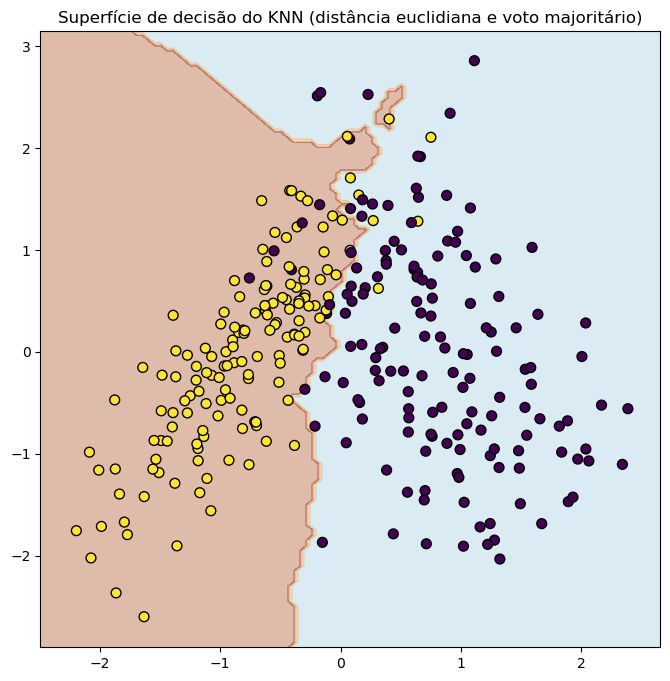

---


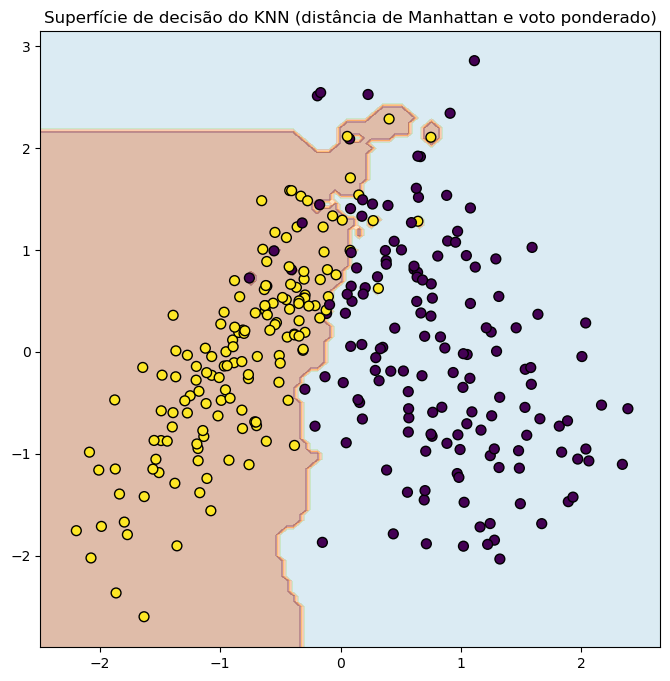

In [25]:
def superficie_decisao_sklearn(X, Y, model, ax, title=""):
    h = .05  # tamanho do passo da malha (mesh)

    # cria uma malha (mesh)
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
     
    X_teste = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(X_teste)
    
    # Converte os valores do vetor para indices
    Z2 = np.unique(Z, return_inverse=True)[1]

    # Desenha a superficie de decisao
    Z2 = Z2.reshape(xx.shape)
    ax.contourf(xx, yy, Z2, cmap=plt.cm.Paired, alpha=.4)

    # Converte os valores do vetor para indices
    Y2 = np.unique(Y, return_inverse=True)[1]

    # Exibe os dados de treinamento
    ax.scatter(X[:, 0], X[:, 1], c=Y2, edgecolor='k', s=50)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title, fontsize='large')
    

# ------------------------------------------------------------------------
# Versão tradicional do modelo (dist euclidiana com voto majoritário)
fig, ax = plt.subplots(figsize=(8, 8)) 
superficie_decisao_sklearn(X2_norm, Y2, KNN_model, ax, title="Superfície de decisão do KNN (distância euclidiana e voto majoritário)")
plt.show()
print('---')

# ------------------------------------------------------------------------
# Versão nova do modelo (dist manhattan com voto ponderado)
fig, ax = plt.subplots(figsize=(8, 8)) 
superficie_decisao_sklearn(X2_norm, Y2, KNN_model_manhattan, ax, title="Superfície de decisão do KNN (distância de Manhattan e voto ponderado)")
plt.show()

Repare como áreas da superfície de decisão se comportam de forma diferente, gerando uma predição diferente a depender da versão adotada do modelo.

Finalmente, vamos comparar as estratégias de armazenamento da distância. Para isso, vamos gerar um novo modelo, que ao invés de calcular as distâncias entre todas as amostras por força bruta para encontrar os $k$-vizinhos mais próximos, utilizará o método **K-D Tree** [3] para organização dos dados.

In [26]:
# Instancia um novo objeto do método KNN
KNN_model_kdtree = KNeighborsClassifier(
    algorithm='kd_tree', # distância armazenada por meio de K-D trees
)

KNN_model_kdtree

KNeighborsClassifier(algorithm='kd_tree')

Finalmente, vamos comparar o tempo de treinamento e predição dos dois modelos. Este resultado pode variar a depender da máquina em que se é executado, mas é esperado que o KNN utilizando K-D Trees seja **2x mais eficiente que o KNN tradicional**.

In [27]:
# Realiza um teste de tempo na versão tradicional do KNN
%timeit KNN_model.fit(X2_norm, Y2).predict(x2_teste_norm)

1.5 ms ± 58.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
# Realiza um teste de tempo na versão do KNN utilizando K-D Tree
%timeit KNN_model_kdtree.fit(X2_norm, Y2).predict(x2_teste_norm)

1.02 ms ± 40.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


---
## Conclusão

Neste notebook, foi apresentado o algoritmo de $k$-vizinhos mais próximos (KNN), técnica de aprendizado de máquina que se utiliza do conceito de distância entre amostras para predizer a classe de uma amostra nova. Inicialmente, foi apresentada a técnica de normalização dos dados, de forma a se evitar problemas de escala dos dados que podem afetar negativamente o KNN. Em seguida, foi implementado o classificador utilizando distância euclidiana. Finalmente, foram apresentadas variações do KNN utilizando a biblioteca ```scikit-learn``, aplicando outras funções de distância, seleção de classe e armazenamento dos dados.

Espera-se que com o conteúdo deste notebook você já esteja pronto para aplicar um dos algoritmos mais tradicionais da área em qualquer conjunto de dados. Por ser simples e apresentar bons resultados a depender da estrutura dos dados, o KNN é um excelente ponto de partida para diversos problemas de classificação.

---
## Referências

[1] T. Cover, and P. Hart. Nearest neighbor pattern classification. IEEE Transactions on Information Theory, Volume 13, Issue 1, 21-27 (1967). DOI: [10.1109/TIT.1967.1053964](https://doi.org/10.1109/TIT.1967.1053964)

[2] R. A. Fisher. The use of multiple measurements in taxonomic problems. Annual Eugenics, Volume 7, Part II, 179-188 (1936). DOI: [10.1111/j.1469-1809.1936.tb02137.x](http://dx.doi.org/10.1111/j.1469-1809.1936.tb02137.x).

[3] J. H. Friedman, J. L. Bentley, and R. A. Finkel. An Algorithm for Finding Best Matches in Logarithmic Expected Time. ACM Transactions on Mathematical Software (TOMS), Volume 3, Issue 3, 209-226 (1977). DOI: [10.1145/355744.355745](https://doi.org/10.1145/355744.355745).

[4] Pedregosa _et al._. Scikit-learn: Machine Learning in Python, JMLR, Volume 12, Issue 85, 2825-2830 (2011).